In [ ]:
!pip install -q xgboost torch scikit-learn pandas numpy matplotlib

import os
import json
import math
import time
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    log_loss,
    accuracy_score,
    f1_score,
    brier_score_loss,
)
from sklearn.calibration import calibration_curve

import xgboost as xgb

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_raw = pd.read_csv(
    '/content/drive/MyDrive/football_match_prediction/train.csv',
    low_memory=False
)

test_raw = pd.read_csv(
    '/content/drive/MyDrive/football_match_prediction/test.csv',
    low_memory=False
)

scores_raw = pd.read_csv(
    '/content/drive/MyDrive/football_match_prediction/train_target_and_scores.csv',
    low_memory=False
)

print("train.csv  :", train_raw.shape)
print("test.csv   :", test_raw.shape)
print("scores.csv :", scores_raw.shape)


train.csv  : (110938, 190)
test.csv   : (72711, 189)
scores.csv : (110938, 3)


In [ ]:
print("train.csv columns (first 15):")
print(list(train_raw.columns[:15]))
print()
print("Does test.csv contain a target column?", "target" in test_raw.columns)
print()
print("train_target_and_scores.csv columns:", list(scores_raw.columns))
scores_raw.head()


train.csv columns (first 15):
['id', 'target', 'home_team_name', 'away_team_name', 'match_date', 'league_name', 'league_id', 'is_cup', 'home_team_coach_id', 'away_team_coach_id', 'home_team_history_match_date_1', 'home_team_history_match_date_2', 'home_team_history_match_date_3', 'home_team_history_match_date_4', 'home_team_history_match_date_5']

Does test.csv contain a target column? False

train_target_and_scores.csv columns: ['id', 'score', 'target']


,id,score,target
0,11906497,2-3,away
1,11984383,1-0,home
2,11983301,2-2,draw
3,11983471,1-2,away
4,11883005,1-0,home


In [ ]:
# Column groups: every "history" feature is suffixed _1..._10 for both
# home_team_history_* and away_team_history_*. _1 = most recent past match,
# _10 = furthest back. Confirm this and see what fields exist per historical match.
hist_fields = sorted(set(
    c.rsplit("_", 1)[0].replace("home_team_history_", "").replace("away_team_history_", "")
    for c in train_raw.columns
    if "_history_" in c and c.rsplit("_", 1)[-1].isdigit()
))
print("Per-historical-match fields available:", hist_fields)

non_history_cols = [c for c in train_raw.columns if "_history_" not in c]
print()
print("Match-level (non-history) columns:", non_history_cols)


Per-historical-match fields available: ['coach', 'goal', 'is_cup', 'is_play_home', 'league_id', 'match_date', 'opponent_goal', 'opponent_rating', 'rating']

Match-level (non-history) columns: ['id', 'target', 'home_team_name', 'away_team_name', 'match_date', 'league_name', 'league_id', 'is_cup', 'home_team_coach_id', 'away_team_coach_id']


In [ ]:
def target_from_score(score_str):
    home_goals, away_goals = score_str.split("-")
    home_goals, away_goals = int(home_goals), int(away_goals)
    if home_goals > away_goals:
        return "home"
    elif home_goals < away_goals:
        return "away"
    else:
        return "draw"

scores_raw["target_from_score"] = scores_raw["score"].apply(target_from_score)

check = train_raw[["id", "target"]].merge(
    scores_raw[["id", "target_from_score"]], on="id", how="inner"
)
agreement = (check["target"] == check["target_from_score"]).mean()
print(f"Rows matched by id: {len(check)} / {len(train_raw)}")
print(f"Target derived from score agrees with train.csv's target column: {agreement:.4%}")
assert agreement == 1.0, "Derived target disagrees with provided target — investigate before proceeding."

# Use the score-derived target going forward (this is what the task asks for),
# merged onto the full training frame.
train_df = train_raw.merge(scores_raw[["id", "target_from_score"]], on="id", how="left")
train_df = train_df.rename(columns={"target_from_score": "y"})
train_df["y"].value_counts()


Rows matched by id: 110938 / 110938
Target derived from score agrees with train.csv's target column: 100.0000%


,count
y,
home,48113
away,35174
draw,27651


In [ ]:
train_df["match_date"] = pd.to_datetime(train_df["match_date"])
test_raw["match_date"] = pd.to_datetime(test_raw["match_date"])

print("train.csv date range:", train_df["match_date"].min(), "->", train_df["match_date"].max())
print("test.csv  date range:", test_raw["match_date"].min(), "->", test_raw["match_date"].max())

train_df = train_df.sort_values("match_date").reset_index(drop=True)

VAL_FRACTION = 0.15
cutoff_idx = int(len(train_df) * (1 - VAL_FRACTION))
cutoff_date = train_df.iloc[cutoff_idx]["match_date"]

is_train = train_df["match_date"] < cutoff_date
tr_df = train_df.loc[is_train].reset_index(drop=True)
va_df = train_df.loc[~is_train].reset_index(drop=True)

print(f"\nChronological split cutoff: {cutoff_date}")
print(f"Train rows: {len(tr_df)}  ({tr_df['match_date'].min()} -> {tr_df['match_date'].max()})")
print(f"Val rows  : {len(va_df)}  ({va_df['match_date'].min()} -> {va_df['match_date'].max()})")
print()
print("Train class balance:\n", tr_df["y"].value_counts(normalize=True))
print("\nVal class balance:\n", va_df["y"].value_counts(normalize=True))


train.csv date range: 2019-12-01 00:45:00 -> 2021-05-01 00:00:00
test.csv  date range: 2021-05-01 00:15:00 -> 2021-11-30 23:30:00

Chronological split cutoff: 2021-03-10 13:30:00
Train rows: 94279  (2019-12-01 00:45:00 -> 2021-03-10 13:15:00)
Val rows  : 16659  (2021-03-10 13:30:00 -> 2021-05-01 00:00:00)

Train class balance:
 y
home    0.434614
away    0.317229
draw    0.248157
Name: proportion, dtype: float64

Val class balance:
 y
home    0.428477
away    0.316105
draw    0.255417
Name: proportion, dtype: float64


In [ ]:
HIST_K_MAX = 10

def team_history_cols(prefix, k):
    # prefix is 'home_team' or 'away_team'
    return {
        "goal":       [f"{prefix}_history_goal_{i}" for i in range(1, k + 1)],
        "opp_goal":   [f"{prefix}_history_opponent_goal_{i}" for i in range(1, k + 1)],
        "rating":     [f"{prefix}_history_rating_{i}" for i in range(1, k + 1)],
        "opp_rating": [f"{prefix}_history_opponent_rating_{i}" for i in range(1, k + 1)],
        "is_home":    [f"{prefix}_history_is_play_home_{i}" for i in range(1, k + 1)],
        "is_cup":     [f"{prefix}_history_is_cup_{i}" for i in range(1, k + 1)],
    }


def aggregate_team_features(df, prefix, k):
    '''Hand-engineered aggregate features over a team's last k matches,
    used by the XGBoost tabular model. Returns a DataFrame indexed like df.'''
    cols = team_history_cols(prefix, k)
    goal = df[cols["goal"]].to_numpy(dtype=float)
    opp_goal = df[cols["opp_goal"]].to_numpy(dtype=float)
    rating = df[cols["rating"]].to_numpy(dtype=float)
    opp_rating = df[cols["opp_rating"]].to_numpy(dtype=float)
    is_home = df[cols["is_home"]].to_numpy(dtype=float)
    is_cup = df[cols["is_cup"]].to_numpy(dtype=float)

    valid = ~np.isnan(goal)
    n_valid = valid.sum(axis=1)
    n_valid_safe = np.where(n_valid == 0, 1, n_valid)

    win = (goal > opp_goal) & valid
    draw = (goal == opp_goal) & valid
    loss = (goal < opp_goal) & valid

    win_rate = win.sum(axis=1) / n_valid_safe
    draw_rate = draw.sum(axis=1) / n_valid_safe
    loss_rate = loss.sum(axis=1) / n_valid_safe

    goal_diff = goal - opp_goal
    with np.errstate(invalid="ignore"):
        avg_goals_for = np.nanmean(goal, axis=1)
        avg_goals_against = np.nanmean(opp_goal, axis=1)
        avg_goal_diff = np.nanmean(goal_diff, axis=1)
        avg_rating = np.nanmean(rating, axis=1)
        avg_opp_rating = np.nanmean(opp_rating, axis=1)
        avg_rating_diff = np.nanmean(rating - opp_rating, axis=1)
    cup_ratio = np.nansum(is_cup, axis=1) / n_valid_safe
    form_points = (win.sum(axis=1) * 3 + draw.sum(axis=1) * 1) / n_valid_safe

    # Separate home-form vs away-form within the history window.
    home_mask = valid & (is_home == 1)
    away_mask = valid & (is_home == 0)
    n_home = home_mask.sum(axis=1)
    n_away = away_mask.sum(axis=1)
    n_home_safe = np.where(n_home == 0, 1, n_home)
    n_away_safe = np.where(n_away == 0, 1, n_away)

    home_win_rate = (win & home_mask).sum(axis=1) / n_home_safe
    away_win_rate = (win & away_mask).sum(axis=1) / n_away_safe
    home_goal_diff = np.nansum(np.where(home_mask, goal_diff, 0), axis=1) / n_home_safe
    away_goal_diff = np.nansum(np.where(away_mask, goal_diff, 0), axis=1) / n_away_safe

    feats = pd.DataFrame({
        f"{prefix}_n_matches": n_valid,
        f"{prefix}_win_rate": win_rate,
        f"{prefix}_draw_rate": draw_rate,
        f"{prefix}_loss_rate": loss_rate,
        f"{prefix}_avg_goals_for": avg_goals_for,
        f"{prefix}_avg_goals_against": avg_goals_against,
        f"{prefix}_avg_goal_diff": avg_goal_diff,
        f"{prefix}_avg_rating": avg_rating,
        f"{prefix}_avg_opp_rating": avg_opp_rating,
        f"{prefix}_avg_rating_diff": avg_rating_diff,
        f"{prefix}_cup_ratio": cup_ratio,
        f"{prefix}_form_points": form_points,
        f"{prefix}_home_win_rate": home_win_rate,
        f"{prefix}_away_win_rate": away_win_rate,
        f"{prefix}_home_goal_diff": home_goal_diff,
        f"{prefix}_away_goal_diff": away_goal_diff,
    }, index=df.index)

    # Neutral fills for teams with zero history in the window (brand-new teams).
    neutral_fill = {
        f"{prefix}_win_rate": 1 / 3, f"{prefix}_draw_rate": 1 / 3, f"{prefix}_loss_rate": 1 / 3,
        f"{prefix}_avg_goals_for": 0.0, f"{prefix}_avg_goals_against": 0.0, f"{prefix}_avg_goal_diff": 0.0,
        f"{prefix}_avg_rating_diff": 0.0,
        f"{prefix}_cup_ratio": 0.0, f"{prefix}_form_points": 1.0,
        f"{prefix}_home_win_rate": 1 / 3, f"{prefix}_away_win_rate": 1 / 3,
        f"{prefix}_home_goal_diff": 0.0, f"{prefix}_away_goal_diff": 0.0,
    }
    for c, v in neutral_fill.items():
        feats[c] = feats[c].fillna(v)
    # avg_rating / avg_opp_rating are left with NaN here on purpose — they are
    # imputed downstream with a TRAIN-ONLY median to avoid any leakage.
    return feats


def build_sequences(df, prefix, k):
    '''Build (N, k, F) sequences in chronological order (oldest -> most recent)
    plus a boolean validity mask of the same (N, k) shape, for the LSTM/Transformer.
    Feature order per timestep: [goal, opp_goal, goal_diff, rating, opp_rating,
    rating_diff, is_play_home, is_cup].
    '''
    cols = team_history_cols(prefix, k)
    goal = df[cols["goal"]].to_numpy(dtype=float)
    opp_goal = df[cols["opp_goal"]].to_numpy(dtype=float)
    rating = df[cols["rating"]].to_numpy(dtype=float)
    opp_rating = df[cols["opp_rating"]].to_numpy(dtype=float)
    is_home = df[cols["is_home"]].to_numpy(dtype=float)
    is_cup = df[cols["is_cup"]].to_numpy(dtype=float)

    valid = ~np.isnan(goal)
    goal_diff = goal - opp_goal
    rating_diff = rating - opp_rating

    seq = np.stack(
        [goal, opp_goal, goal_diff, rating, opp_rating, rating_diff, is_home, is_cup],
        axis=-1,
    )
    seq = np.nan_to_num(seq, nan=0.0)

    # Slot _1 is most recent, _k is oldest -> reverse so index 0 = oldest, index k-1 = most recent.
    seq = seq[:, ::-1, :].copy()
    mask = valid[:, ::-1].copy()

    # Edge case: a handful of brand-new teams have zero history at all. Mark the
    # last (most recent) slot valid as a neutral placeholder so downstream
    # packing / attention masking never sees an all-False row.
    zero_hist = ~mask.any(axis=1)
    if zero_hist.any():
        mask[zero_hist, -1] = True

    return seq.astype(np.float32), mask

print("Utilities defined.")


Utilities defined.


In [ ]:
def build_cross_features(home_feats, away_feats, prefix_h="home_team", prefix_a="away_team"):
    return pd.DataFrame({
        "rating_diff": home_feats[f"{prefix_h}_avg_rating"] - away_feats[f"{prefix_a}_avg_rating"],
        "opp_rating_diff": home_feats[f"{prefix_h}_avg_opp_rating"] - away_feats[f"{prefix_a}_avg_opp_rating"],
        "win_rate_diff": home_feats[f"{prefix_h}_win_rate"] - away_feats[f"{prefix_a}_win_rate"],
        "draw_rate_diff": home_feats[f"{prefix_h}_draw_rate"] - away_feats[f"{prefix_a}_draw_rate"],
        "goal_diff_diff": home_feats[f"{prefix_h}_avg_goal_diff"] - away_feats[f"{prefix_a}_avg_goal_diff"],
        "form_points_diff": home_feats[f"{prefix_h}_form_points"] - away_feats[f"{prefix_a}_form_points"],
        # Home team's home-form vs away team's away-form: the most relevant
        # "specific" comparison for a match that will be played at the home team's ground.
        "specific_form_diff": home_feats[f"{prefix_h}_home_win_rate"] - away_feats[f"{prefix_a}_away_win_rate"],
        "n_matches_diff": home_feats[f"{prefix_h}_n_matches"] - away_feats[f"{prefix_a}_n_matches"],
    }, index=home_feats.index)


class TabularFeatureBuilder:
    '''Fits imputation / encoding stats on a training frame, then transforms
    any frame (train, val, or test) consistently -- no leakage.'''

    def __init__(self, k):
        self.k = k
        self.rating_medians_ = {}
        self.team_categories_ = None
        self.league_categories_ = None

    def fit(self, df):
        home_feats = aggregate_team_features(df, "home_team", self.k)
        away_feats = aggregate_team_features(df, "away_team", self.k)
        self.rating_medians_["home_team_avg_rating"] = home_feats["home_team_avg_rating"].median()
        self.rating_medians_["home_team_avg_opp_rating"] = home_feats["home_team_avg_opp_rating"].median()
        self.rating_medians_["away_team_avg_rating"] = away_feats["away_team_avg_rating"].median()
        self.rating_medians_["away_team_avg_opp_rating"] = away_feats["away_team_avg_opp_rating"].median()

        all_teams = pd.concat([df["home_team_name"], df["away_team_name"]]).unique()
        self.team_categories_ = pd.Categorical(all_teams).categories
        self.league_categories_ = pd.Categorical(df["league_id"].dropna()).categories
        return self

    def transform(self, df):
        home_feats = aggregate_team_features(df, "home_team", self.k)
        away_feats = aggregate_team_features(df, "away_team", self.k)
        for col, med in self.rating_medians_.items():
            (home_feats if col.startswith("home") else away_feats)[col] = (
                (home_feats if col.startswith("home") else away_feats)[col].fillna(med)
            )
        cross_feats = build_cross_features(home_feats, away_feats)

        context = pd.DataFrame({
            "is_cup": df["is_cup"].fillna(False).astype(int).to_numpy(),
            "home_team_code": pd.Categorical(df["home_team_name"], categories=self.team_categories_).codes,
            "away_team_code": pd.Categorical(df["away_team_name"], categories=self.team_categories_).codes,
            "league_code": pd.Categorical(df["league_id"], categories=self.league_categories_).codes,
        }, index=df.index)

        X = pd.concat([home_feats, away_feats, cross_feats, context], axis=1)
        return X

    def fit_transform(self, df):
        return self.fit(df).transform(df)


tab_builder = TabularFeatureBuilder(k=10)
X_tr = tab_builder.fit_transform(tr_df)
X_va = tab_builder.transform(va_df)

label_map = {"home": 0, "draw": 1, "away": 2}
inv_label_map = {v: k for k, v in label_map.items()}
y_tr = tr_df["y"].map(label_map).to_numpy()
y_va = va_df["y"].map(label_map).to_numpy()

print("X_tr:", X_tr.shape, " X_va:", X_va.shape)
X_tr.head()


X_tr: (94279, 44)  X_va: (16659, 44)


,home_team_n_matches,home_team_win_rate,home_team_draw_rate,home_team_loss_rate,home_team_avg_goals_for,home_team_avg_goals_against,home_team_avg_goal_diff,home_team_avg_rating,home_team_avg_opp_rating,home_team_avg_rating_diff,...,win_rate_diff,draw_rate_diff,goal_diff_diff,form_points_diff,specific_form_diff,n_matches_diff,is_cup,home_team_code,away_team_code,league_code
0,10,0.4,0.3,0.3,1.3,1.0,0.3,5.496371,4.400204,1.096167,...,-0.2,0.2,-0.4,-0.4,0.35,0,0,6055,7277,198
1,10,0.3,0.1,0.6,0.9,1.0,-0.1,8.440839,4.546772,3.894067,...,0.0,-0.1,0.5,-0.1,0.40,0,0,7131,2442,227
2,10,0.4,0.3,0.3,1.9,1.7,0.2,6.844712,5.547477,1.297235,...,-0.2,0.0,-0.8,-0.6,-0.20,0,0,8984,5455,222
3,10,0.4,0.4,0.2,1.8,1.3,0.5,7.449923,4.983015,2.466908,...,0.0,0.1,0.1,0.1,0.00,0,0,5054,5798,224
4,10,0.5,0.3,0.2,1.8,1.4,0.4,7.079634,5.192975,1.886660,...,0.0,0.0,-0.4,0.0,0.60,0,0,2089,4266,218


## 5. Model 1 — XGBoost Tabular Baseline


In [ ]:
xgb_clf = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=SEED,
    n_jobs=-1,
)

t0 = time.time()
xgb_clf.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_va, y_va)],
    verbose=50,
)
print(f"XGBoost trained in {time.time() - t0:.1f}s")

xgb_val_proba = xgb_clf.predict_proba(X_va)
xgb_val_pred = xgb_val_proba.argmax(axis=1)
print("Val accuracy:", accuracy_score(y_va, xgb_val_pred))
print("Val log loss:", log_loss(y_va, xgb_val_proba, labels=[0, 1, 2]))


[0]	validation_0-mlogloss:1.06806	validation_1-mlogloss:1.07174
[50]	validation_0-mlogloss:1.00646	validation_1-mlogloss:1.01379
[100]	validation_0-mlogloss:0.99508	validation_1-mlogloss:1.00984
[150]	validation_0-mlogloss:0.98693	validation_1-mlogloss:1.00921
[200]	validation_0-mlogloss:0.97960	validation_1-mlogloss:1.00909
[250]	validation_0-mlogloss:0.97272	validation_1-mlogloss:1.00919
[300]	validation_0-mlogloss:0.96574	validation_1-mlogloss:1.00928
[350]	validation_0-mlogloss:0.95939	validation_1-mlogloss:1.00938
[399]	validation_0-mlogloss:0.95316	validation_1-mlogloss:1.00960
XGBoost trained in 22.6s
Val accuracy: 0.49792904736178645
Val log loss: 1.0096027900495654


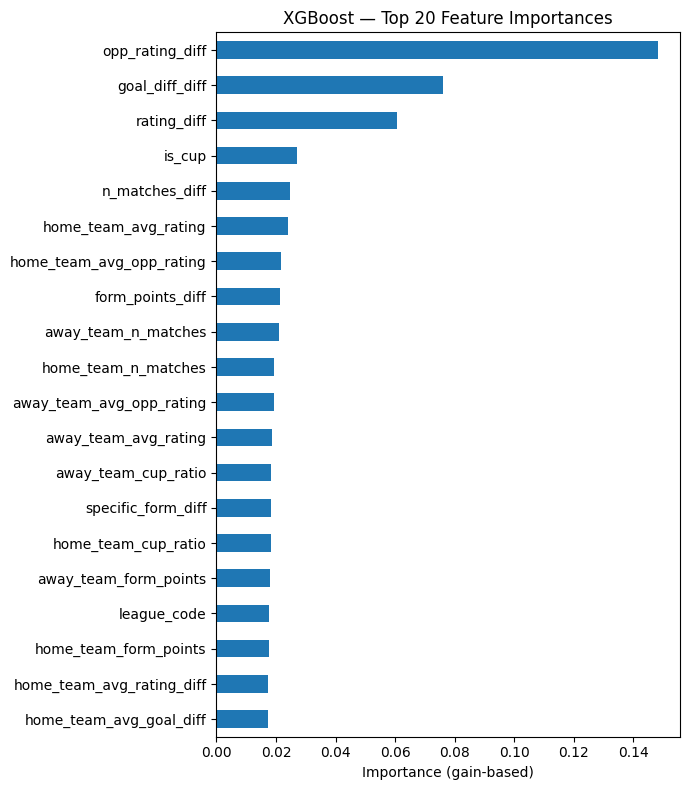

In [ ]:
# Feature importance -- sanity check that the model is using sensible signals.
importances = pd.Series(xgb_clf.feature_importances_, index=X_tr.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 8))
importances.head(20).iloc[::-1].plot.barh(ax=ax)
ax.set_title("XGBoost — Top 20 Feature Importances")
ax.set_xlabel("Importance (gain-based)")
plt.tight_layout()
plt.show()


In [ ]:
def fit_seq_scaler(seq, mask):
    # Fit a StandardScaler on valid (non-padded) timesteps only.
    flat = seq[mask]  # (num_valid_timesteps, F)
    scaler = StandardScaler()
    scaler.fit(flat)
    return scaler


def apply_seq_scaler(seq, mask, scaler):
    N, K, F = seq.shape
    flat = seq.reshape(-1, F)
    flat_scaled = scaler.transform(flat)
    seq_scaled = flat_scaled.reshape(N, K, F)
    seq_scaled = seq_scaled * mask[..., None]  # re-zero padded positions
    return seq_scaled.astype(np.float32)


def make_sequence_dataset(df, k, scaler_home=None, scaler_away=None, fit_scalers=False):
    seq_h, mask_h = build_sequences(df, "home_team", k)
    seq_a, mask_a = build_sequences(df, "away_team", k)

    if fit_scalers:
        scaler_home = fit_seq_scaler(seq_h, mask_h)
        scaler_away = fit_seq_scaler(seq_a, mask_a)

    seq_h = apply_seq_scaler(seq_h, mask_h, scaler_home)
    seq_a = apply_seq_scaler(seq_a, mask_a, scaler_away)

    return {
        "seq_h": seq_h, "mask_h": mask_h,
        "seq_a": seq_a, "mask_a": mask_a,
        "scaler_home": scaler_home, "scaler_away": scaler_away,
    }


K_DEFAULT = 10
seq_tr = make_sequence_dataset(tr_df, K_DEFAULT, fit_scalers=True)
seq_va = make_sequence_dataset(
    va_df, K_DEFAULT,
    scaler_home=seq_tr["scaler_home"], scaler_away=seq_tr["scaler_away"],
    fit_scalers=False,
)

print("Home sequence shape (train):", seq_tr["seq_h"].shape)
print("Away sequence shape (train):", seq_tr["seq_a"].shape)
print("Mean valid-history length (train, home):", seq_tr["mask_h"].sum(axis=1).mean().round(2))


Home sequence shape (train): (94279, 10, 8)
Away sequence shape (train): (94279, 10, 8)
Mean valid-history length (train, home): 9.31


In [ ]:
class MatchSequenceDataset(Dataset):
    # Wraps home/away sequences, masks, and integer labels for PyTorch.

    def __init__(self, seq_h, mask_h, seq_a, mask_a, y=None):
        self.seq_h = torch.from_numpy(seq_h).float()
        self.mask_h = torch.from_numpy(mask_h).bool()
        self.seq_a = torch.from_numpy(seq_a).float()
        self.mask_a = torch.from_numpy(mask_a).bool()
        self.y = torch.from_numpy(y).long() if y is not None else None

    def __len__(self):
        return self.seq_h.shape[0]

    def __getitem__(self, idx):
        item = {
            "seq_h": self.seq_h[idx], "mask_h": self.mask_h[idx],
            "seq_a": self.seq_a[idx], "mask_a": self.mask_a[idx],
        }
        if self.y is not None:
            item["y"] = self.y[idx]
        return item


BATCH_SIZE = 256

train_ds = MatchSequenceDataset(seq_tr["seq_h"], seq_tr["mask_h"], seq_tr["seq_a"], seq_tr["mask_a"], y_tr)
val_ds = MatchSequenceDataset(seq_va["seq_h"], seq_va["mask_h"], seq_va["seq_a"], seq_va["mask_a"], y_va)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

FEATURES_PER_MATCH = seq_tr["seq_h"].shape[-1]
print("Features per historical match:", FEATURES_PER_MATCH)
print("Train batches:", len(train_loader), " Val batches:", len(val_loader))


Features per historical match: 8
Train batches: 369  Val batches: 66


In [ ]:
class LSTMTeamEncoder(nn.Module):
    def __init__(self, in_features, hidden_size=32, proj_size=32):
        super().__init__()
        self.proj = nn.Linear(in_features, proj_size)
        self.act = nn.ReLU()
        self.lstm = nn.LSTM(proj_size, hidden_size, batch_first=True)

    def forward(self, seq, mask):
        # seq: (B, K, F), mask: (B, K) bool
        lengths = mask.sum(dim=1).clamp(min=1).cpu()
        x = self.act(self.proj(seq))
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths, batch_first=True, enforce_sorted=False
        )
        _, (h_n, _) = self.lstm(packed)
        return h_n[-1]  # (B, hidden_size) -- last layer's final hidden state


class LSTMMatchModel(nn.Module):
    def __init__(self, in_features, hidden_size=32, fc_hidden=64, n_classes=3, dropout=0.2):
        super().__init__()
        self.home_encoder = LSTMTeamEncoder(in_features, hidden_size)
        self.away_encoder = LSTMTeamEncoder(in_features, hidden_size)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, fc_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_hidden, n_classes),
        )

    def forward(self, seq_h, mask_h, seq_a, mask_a):
        h = self.home_encoder(seq_h, mask_h)
        a = self.away_encoder(seq_a, mask_a)
        z = torch.cat([h, a], dim=1)
        return self.fc(z)


print(LSTMMatchModel(FEATURES_PER_MATCH))


LSTMMatchModel(
  (home_encoder): LSTMTeamEncoder(
    (proj): Linear(in_features=8, out_features=32, bias=True)
    (act): ReLU()
    (lstm): LSTM(32, 32, batch_first=True)
  )
  (away_encoder): LSTMTeamEncoder(
    (proj): Linear(in_features=8, out_features=32, bias=True)
    (act): ReLU()
    (lstm): LSTM(32, 32, batch_first=True)
  )
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=3, bias=True)
  )
)


In [ ]:
def run_training_loop(model, train_loader, val_loader, n_epochs=15, lr=1e-3, weight_decay=1e-4, label=""):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": []}
    for epoch in range(1, n_epochs + 1):
        model.train()
        running_loss, n_seen = 0.0, 0
        for batch in train_loader:
            seq_h = batch["seq_h"].to(DEVICE)
            mask_h = batch["mask_h"].to(DEVICE)
            seq_a = batch["seq_a"].to(DEVICE)
            mask_a = batch["mask_a"].to(DEVICE)
            y = batch["y"].to(DEVICE)

            optimizer.zero_grad()
            logits = model(seq_h, mask_h, seq_a, mask_a)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * y.size(0)
            n_seen += y.size(0)
        train_loss = running_loss / n_seen

        model.eval()
        running_loss, n_seen = 0.0, 0
        with torch.no_grad():
            for batch in val_loader:
                seq_h = batch["seq_h"].to(DEVICE)
                mask_h = batch["mask_h"].to(DEVICE)
                seq_a = batch["seq_a"].to(DEVICE)
                mask_a = batch["mask_a"].to(DEVICE)
                y = batch["y"].to(DEVICE)
                logits = model(seq_h, mask_h, seq_a, mask_a)
                loss = criterion(logits, y)
                running_loss += loss.item() * y.size(0)
                n_seen += y.size(0)
        val_loss = running_loss / n_seen

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        print(f"[{label}] epoch {epoch:02d}/{n_epochs}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

    return history


@torch.no_grad()
def predict_proba_torch(model, loader):
    model.eval()
    all_probs = []
    for batch in loader:
        seq_h = batch["seq_h"].to(DEVICE)
        mask_h = batch["mask_h"].to(DEVICE)
        seq_a = batch["seq_a"].to(DEVICE)
        mask_a = batch["mask_a"].to(DEVICE)
        logits = model(seq_h, mask_h, seq_a, mask_a)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        all_probs.append(probs)
    return np.concatenate(all_probs, axis=0)


In [ ]:
torch.manual_seed(SEED)
lstm_model = LSTMMatchModel(FEATURES_PER_MATCH, hidden_size=32, fc_hidden=64)
lstm_history = run_training_loop(lstm_model, train_loader, val_loader, n_epochs=15, lr=1e-3, label="LSTM")


[LSTM] epoch 01/15  train_loss=1.0291  val_loss=1.0136
[LSTM] epoch 02/15  train_loss=1.0193  val_loss=1.0162
[LSTM] epoch 03/15  train_loss=1.0184  val_loss=1.0122
[LSTM] epoch 04/15  train_loss=1.0178  val_loss=1.0149
[LSTM] epoch 05/15  train_loss=1.0172  val_loss=1.0117
[LSTM] epoch 06/15  train_loss=1.0170  val_loss=1.0174
[LSTM] epoch 07/15  train_loss=1.0161  val_loss=1.0145
[LSTM] epoch 08/15  train_loss=1.0163  val_loss=1.0126
[LSTM] epoch 09/15  train_loss=1.0153  val_loss=1.0130
[LSTM] epoch 10/15  train_loss=1.0155  val_loss=1.0107
[LSTM] epoch 11/15  train_loss=1.0152  val_loss=1.0117
[LSTM] epoch 12/15  train_loss=1.0157  val_loss=1.0113
[LSTM] epoch 13/15  train_loss=1.0150  val_loss=1.0151
[LSTM] epoch 14/15  train_loss=1.0148  val_loss=1.0109
[LSTM] epoch 15/15  train_loss=1.0146  val_loss=1.0131


In [ ]:
lstm_val_proba = predict_proba_torch(lstm_model, val_loader)
lstm_val_pred = lstm_val_proba.argmax(axis=1)
print("LSTM val accuracy:", accuracy_score(y_va, lstm_val_pred))
print("LSTM val log loss:", log_loss(y_va, lstm_val_proba, labels=[0, 1, 2]))


LSTM val accuracy: 0.49180623086619846
LSTM val log loss: 1.0130707567379753


In [ ]:
class LearnedPositionalEncoding(nn.Module):
    def __init__(self, seq_len, d_model):
        super().__init__()
        self.pos_embed = nn.Parameter(torch.randn(1, seq_len, d_model) * 0.02)

    def forward(self, x):
        return x + self.pos_embed[:, : x.size(1), :]


class TransformerTeamEncoder(nn.Module):
    def __init__(self, in_features, seq_len, d_model=32, n_heads=4, n_layers=2, ff_dim=64, dropout=0.1):
        super().__init__()
        self.proj = nn.Linear(in_features, d_model)
        self.pos_enc = LearnedPositionalEncoding(seq_len, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True, activation="relu",
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

    def forward(self, seq, mask):
        # seq: (B, K, F), mask: (B, K) bool, True = real (non-padded) timestep
        x = self.proj(seq)
        x = self.pos_enc(x)
        padding_mask = ~mask  # True = ignore, as required by nn.TransformerEncoder
        out = self.encoder(x, src_key_padding_mask=padding_mask)  # (B, K, d_model)

        mask_f = mask.unsqueeze(-1).float()
        pooled = (out * mask_f).sum(dim=1) / mask_f.sum(dim=1).clamp(min=1.0)
        return pooled  # (B, d_model)


class TransformerMatchModel(nn.Module):
    def __init__(self, in_features, seq_len, d_model=32, n_heads=4, n_layers=2,
                 fc_hidden=64, n_classes=3, dropout=0.2):
        super().__init__()
        self.home_encoder = TransformerTeamEncoder(in_features, seq_len, d_model, n_heads, n_layers)
        self.away_encoder = TransformerTeamEncoder(in_features, seq_len, d_model, n_heads, n_layers)
        self.fc = nn.Sequential(
            nn.Linear(d_model * 2, fc_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_hidden, n_classes),
        )

    def forward(self, seq_h, mask_h, seq_a, mask_a):
        h = self.home_encoder(seq_h, mask_h)
        a = self.away_encoder(seq_a, mask_a)
        z = torch.cat([h, a], dim=1)
        return self.fc(z)


print(TransformerMatchModel(FEATURES_PER_MATCH, seq_len=K_DEFAULT))


TransformerMatchModel(
  (home_encoder): TransformerTeamEncoder(
    (proj): Linear(in_features=8, out_features=32, bias=True)
    (pos_enc): LearnedPositionalEncoding()
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
          )
          (linear1): Linear(in_features=32, out_features=64, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=64, out_features=32, bias=True)
          (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
  )
  (away_encoder): TransformerTeamEncoder(
    (proj): Linear(in_features=8, out_features=32, bias

In [ ]:
torch.manual_seed(SEED)
transformer_model = TransformerMatchModel(
    FEATURES_PER_MATCH, seq_len=K_DEFAULT, d_model=32, n_heads=4, n_layers=2, fc_hidden=64,
)
transformer_history = run_training_loop(
    transformer_model, train_loader, val_loader, n_epochs=15, lr=1e-3, label="Transformer",
)


[Transformer] epoch 01/15  train_loss=1.0234  val_loss=1.0114
[Transformer] epoch 02/15  train_loss=1.0188  val_loss=1.0125
[Transformer] epoch 03/15  train_loss=1.0168  val_loss=1.0131
[Transformer] epoch 04/15  train_loss=1.0158  val_loss=1.0159
[Transformer] epoch 05/15  train_loss=1.0152  val_loss=1.0099
[Transformer] epoch 06/15  train_loss=1.0149  val_loss=1.0101
[Transformer] epoch 07/15  train_loss=1.0146  val_loss=1.0109
[Transformer] epoch 08/15  train_loss=1.0132  val_loss=1.0084
[Transformer] epoch 09/15  train_loss=1.0128  val_loss=1.0101
[Transformer] epoch 10/15  train_loss=1.0121  val_loss=1.0142
[Transformer] epoch 11/15  train_loss=1.0122  val_loss=1.0081
[Transformer] epoch 12/15  train_loss=1.0121  val_loss=1.0077
[Transformer] epoch 13/15  train_loss=1.0118  val_loss=1.0070
[Transformer] epoch 14/15  train_loss=1.0109  val_loss=1.0078
[Transformer] epoch 15/15  train_loss=1.0110  val_loss=1.0080


In [ ]:
transformer_val_proba = predict_proba_torch(transformer_model, val_loader)
transformer_val_pred = transformer_val_proba.argmax(axis=1)
print("Transformer val accuracy:", accuracy_score(y_va, transformer_val_pred))
print("Transformer val log loss:", log_loss(y_va, transformer_val_proba, labels=[0, 1, 2]))


Transformer val accuracy: 0.4982892130379975
Transformer val log loss: 1.0079545563511947


In [ ]:
def multiclass_brier_score(y_true, y_proba, n_classes=3):
    y_onehot = np.eye(n_classes)[y_true]
    return np.mean(np.sum((y_proba - y_onehot) ** 2, axis=1))


def evaluate_model(name, y_true, y_proba):
    y_pred = y_proba.argmax(axis=1)
    return {
        "model": name,
        "log_loss": log_loss(y_true, y_proba, labels=[0, 1, 2]),
        "brier_score": multiclass_brier_score(y_true, y_proba),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
    }


results = pd.DataFrame([
    evaluate_model("XGBoost", y_va, xgb_val_proba),
    evaluate_model("LSTM", y_va, lstm_val_proba),
    evaluate_model("Transformer", y_va, transformer_val_proba),
]).set_index("model")

results.round(4)


,log_loss,brier_score,accuracy,macro_f1
model,,,,
XGBoost,1.0096,0.6041,0.4979,0.3837
LSTM,1.0131,0.6067,0.4918,0.3605
Transformer,1.0080,0.6030,0.4983,0.3696


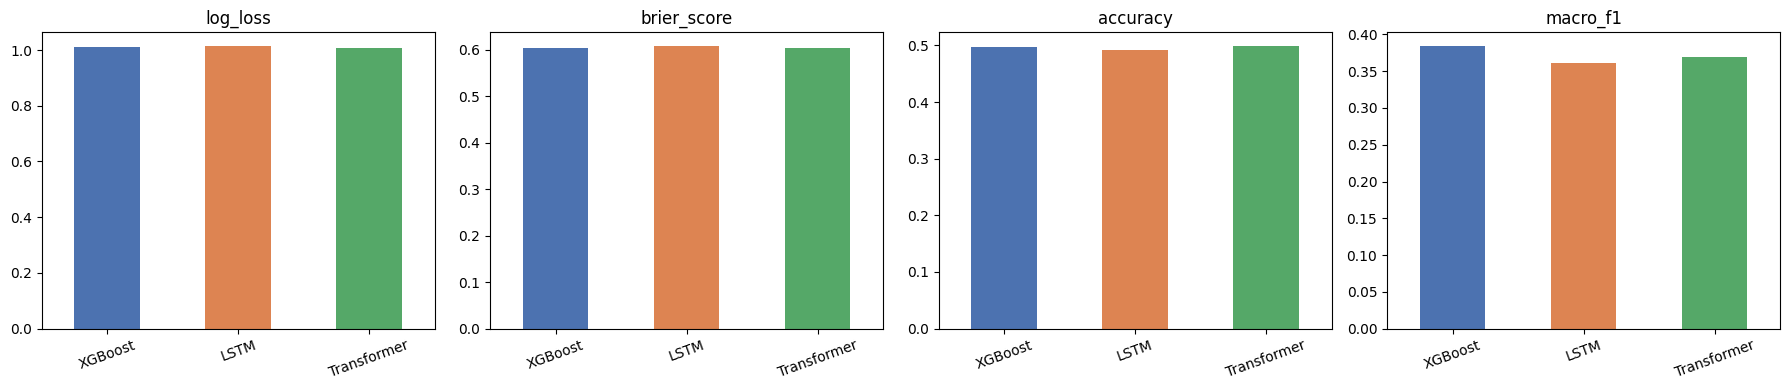

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, metric in zip(axes, ["log_loss", "brier_score", "accuracy", "macro_f1"]):
    results[metric].plot.bar(ax=ax, color=["#4C72B0", "#DD8452", "#55A868"])
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


### 9a. Training / Validation Loss Curves (LSTM vs. Transformer)


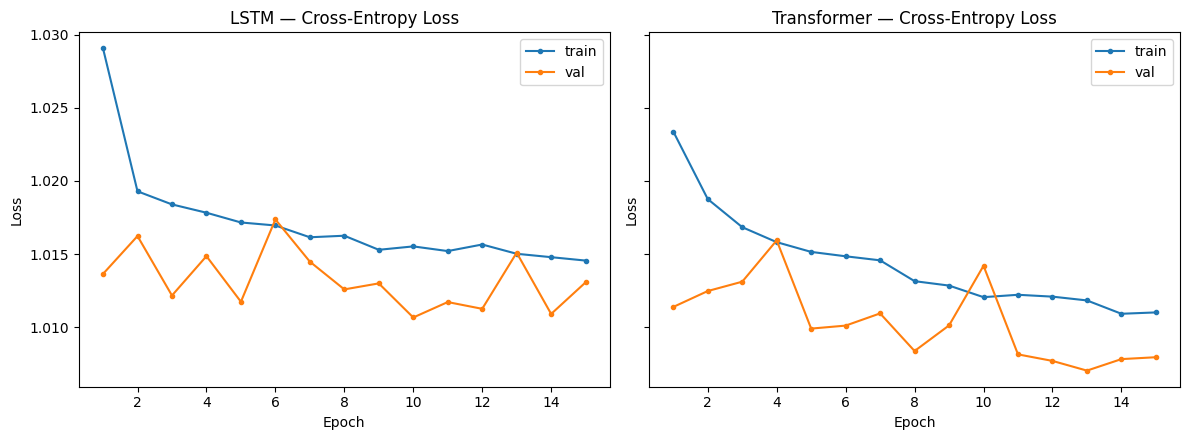

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, (name, hist) in zip(axes, [("LSTM", lstm_history), ("Transformer", transformer_history)]):
    epochs = range(1, len(hist["train_loss"]) + 1)
    ax.plot(epochs, hist["train_loss"], label="train", marker="o", markersize=3)
    ax.plot(epochs, hist["val_loss"], label="val", marker="o", markersize=3)
    ax.set_title(f"{name} — Cross-Entropy Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
def run_ablation_for_k(k, n_epochs=8):
    # --- Tabular / XGBoost ---
    tab_builder_k = TabularFeatureBuilder(k=k)
    X_tr_k = tab_builder_k.fit_transform(tr_df)
    X_va_k = tab_builder_k.transform(va_df)

    xgb_k = xgb.XGBClassifier(
        objective="multi:softprob", num_class=3, n_estimators=250, max_depth=5,
        learning_rate=0.07, subsample=0.8, colsample_bytree=0.8,
        eval_metric="mlogloss", tree_method="hist", random_state=SEED, n_jobs=-1,
    )
    xgb_k.fit(X_tr_k, y_tr, verbose=False)
    xgb_proba_k = xgb_k.predict_proba(X_va_k)

    # --- Sequences / LSTM & Transformer ---
    seq_tr_k = make_sequence_dataset(tr_df, k, fit_scalers=True)
    seq_va_k = make_sequence_dataset(
        va_df, k, scaler_home=seq_tr_k["scaler_home"], scaler_away=seq_tr_k["scaler_away"],
    )
    train_ds_k = MatchSequenceDataset(seq_tr_k["seq_h"], seq_tr_k["mask_h"], seq_tr_k["seq_a"], seq_tr_k["mask_a"], y_tr)
    val_ds_k = MatchSequenceDataset(seq_va_k["seq_h"], seq_va_k["mask_h"], seq_va_k["seq_a"], seq_va_k["mask_a"], y_va)
    train_loader_k = DataLoader(train_ds_k, batch_size=BATCH_SIZE, shuffle=True)
    val_loader_k = DataLoader(val_ds_k, batch_size=BATCH_SIZE, shuffle=False)

    torch.manual_seed(SEED)
    lstm_k = LSTMMatchModel(FEATURES_PER_MATCH, hidden_size=32, fc_hidden=64)
    run_training_loop(lstm_k, train_loader_k, val_loader_k, n_epochs=n_epochs, label=f"LSTM k={k}")
    lstm_proba_k = predict_proba_torch(lstm_k, val_loader_k)

    torch.manual_seed(SEED)
    transformer_k = TransformerMatchModel(FEATURES_PER_MATCH, seq_len=k, d_model=32, n_heads=4, n_layers=2)
    run_training_loop(transformer_k, train_loader_k, val_loader_k, n_epochs=n_epochs, label=f"Transformer k={k}")
    transformer_proba_k = predict_proba_torch(transformer_k, val_loader_k)

    rows = [
        evaluate_model("XGBoost", y_va, xgb_proba_k),
        evaluate_model("LSTM", y_va, lstm_proba_k),
        evaluate_model("Transformer", y_va, transformer_proba_k),
    ]
    for r in rows:
        r["k"] = k
    return rows


ablation_rows = []
for k in [3, 5, 10]:
    print(f"\n===== Ablation: k={k} =====")
    ablation_rows.extend(run_ablation_for_k(k, n_epochs=8))

ablation_df = pd.DataFrame(ablation_rows).set_index(["k", "model"])
ablation_df.round(4)



===== Ablation: k=3 =====
[LSTM k=3] epoch 01/8  train_loss=1.0345  val_loss=1.0240
[LSTM k=3] epoch 02/8  train_loss=1.0269  val_loss=1.0224
[LSTM k=3] epoch 03/8  train_loss=1.0258  val_loss=1.0226
[LSTM k=3] epoch 04/8  train_loss=1.0253  val_loss=1.0269
[LSTM k=3] epoch 05/8  train_loss=1.0249  val_loss=1.0222
[LSTM k=3] epoch 06/8  train_loss=1.0247  val_loss=1.0226
[LSTM k=3] epoch 07/8  train_loss=1.0244  val_loss=1.0225
[LSTM k=3] epoch 08/8  train_loss=1.0243  val_loss=1.0225
[Transformer k=3] epoch 01/8  train_loss=1.0331  val_loss=1.0247
[Transformer k=3] epoch 02/8  train_loss=1.0288  val_loss=1.0245
[Transformer k=3] epoch 03/8  train_loss=1.0276  val_loss=1.0257
[Transformer k=3] epoch 04/8  train_loss=1.0265  val_loss=1.0234
[Transformer k=3] epoch 05/8  train_loss=1.0255  val_loss=1.0242
[Transformer k=3] epoch 06/8  train_loss=1.0254  val_loss=1.0219
[Transformer k=3] epoch 07/8  train_loss=1.0253  val_loss=1.0213
[Transformer k=3] epoch 08/8  train_loss=1.0247  val_l

log_loss  brier_score  accuracy  macro_f1
k  model                                                 
3  XGBoost        1.0247       0.6144    0.4859    0.3682
   LSTM           1.0225       0.6131    0.4863    0.3511
   Transformer    1.0221       0.6128    0.4884    0.3574
5  XGBoost        1.0158       0.6084    0.4935    0.3798
   LSTM           1.0163       0.6087    0.4913    0.3560
   Transformer    1.0156       0.6082    0.4940    0.3603
10 XGBoost        1.0098       0.6042    0.4973    0.3815
   LSTM           1.0126       0.6063    0.4942    0.3577
   Transformer    1.0084       0.6035    0.4979    0.3698

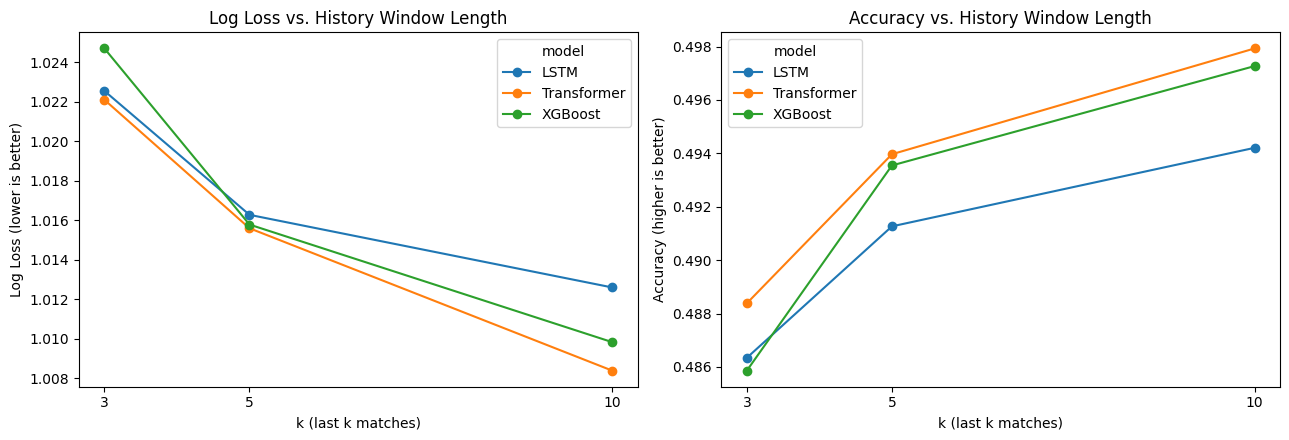

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
pivot_ll = ablation_df["log_loss"].unstack("model")
pivot_acc = ablation_df["accuracy"].unstack("model")

pivot_ll.plot(marker="o", ax=axes[0])
axes[0].set_title("Log Loss vs. History Window Length")
axes[0].set_xlabel("k (last k matches)")
axes[0].set_ylabel("Log Loss (lower is better)")
axes[0].set_xticks([3, 5, 10])

pivot_acc.plot(marker="o", ax=axes[1])
axes[1].set_title("Accuracy vs. History Window Length")
axes[1].set_xlabel("k (last k matches)")
axes[1].set_ylabel("Accuracy (higher is better)")
axes[1].set_xticks([3, 5, 10])

plt.tight_layout()
plt.show()
